In [56]:
# IMPORTAÇÃO DE BIBLIOTECAS
# Este bloco reúne todas as dependências utilizadas no projeto,

# Manipulação e Análise de Dados
import pandas as pd          # Estruturas de dados (DataFrame)
import numpy as np           # Operações matemáticas e vetorização


# Visualização de Dados (EDA)
import matplotlib.pyplot as plt  # Base para geração de gráficos
import seaborn as sns            # Visualizações estatísticas avançadas

# Deep Learning (Rede Neural)
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping  # Parada antecipada para evitar overfitting


# Machine Learning (Pré-processamento e Avaliação)
from sklearn.model_selection import train_test_split  # Divisão treino/teste
from sklearn.preprocessing import StandardScaler      # Normalização de variáveis numéricas
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    accuracy_score
)
from sklearn.calibration import CalibrationDisplay
# ⚠ Correção: LabelEncoder está no módulo preprocessing
from sklearn.preprocessing import LabelEncoder


# A biblioteca Experta utiliza estruturas antigas do módulo
# collections que foram movidas para collections.abc no
# Python 3.10+. O trecho abaixo cria aliases temporários
# para manter compatibilidade.
import collections
import collections.abc

collections.Mapping = collections.abc.Mapping
collections.MutableMapping = collections.abc.MutableMapping
collections.Iterable = collections.abc.Iterable
collections.Sequence = collections.abc.Sequence
collections.Callable = collections.abc.Callable


# Sistema Especialista (IA Simbólica)
from experta import *
import google.generativeai as genai
import time
import os
import google.generativeai as genai
from dotenv import load_dotenv
import random

In [57]:
# CONFIGURAÇÃO GLOBAL DE VISUALIZAÇÃO
# Este bloco define um tema visual personalizado para todos
# os gráficos do projeto utilizando matplotlib.

plt.rcParams.update({

    # Cor de fundo da figura inteira
    "figure.facecolor": "#0A1428",

    # Cor de fundo da área do gráfico
    "axes.facecolor": "#10203A",

    # Cor das bordas dos eixos
    "axes.edgecolor": "#00FFFF",

    # Cor dos rótulos dos eixos
    "axes.labelcolor": "#FFFFFF",

    # Cor dos valores no eixo X
    "xtick.color": "#AAAAAA",

    # Cor dos valores no eixo Y
    "ytick.color": "#AAAAAA",

    # Cor padrão dos textos (títulos, legendas)
    "text.color": "#FFFFFF",

    # Configuração da grade
    "grid.color": "#1A3A5A",
    "grid.linestyle": "--",
})

In [58]:
# Carregamento do Dataset

df_rnn = pd.read_csv("dataset/ai_job_dataset.csv")
print("✅ Dataset carregado com sucesso!")

✅ Dataset carregado com sucesso!


### EDA

In [59]:
# Exibe as primeiras linhas do dataset para validação manual da estrutura e verificação de colunas esperadas.

df_rnn.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [60]:
# Verificação do tipo da estrutura carregada e dimensões do DataFrame (linhas x colunas)

print(type(df_rnn))  # Deve ser pandas.core.frame.DataFrame
df_rnn.shape         # Retorna (n_linhas, n_colunas)

<class 'pandas.core.frame.DataFrame'>


(15000, 19)

In [61]:
# Exibe informações estruturais:
# - Tipo de cada coluna
# - Quantidade de valores não-nulos
# - Uso de memória
df_rnn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [62]:
# Gera métricas estatísticas básicas:
# - Média
# - Desvio padrão
# - Mínimo e máximo
# - Quartis
df_rnn.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [63]:
# Conta o número de valores nulos por coluna.
# Essencial para decidir estratégia de tratamento
# (remoção, imputação, etc.)
print("Valores ausentes por coluna:")

# Percentual de dados ausentes
(df_rnn.isnull().sum() / len(df_rnn)) * 100

Valores ausentes por coluna:


job_id                    0.0
job_title                 0.0
salary_usd                0.0
salary_currency           0.0
experience_level          0.0
employment_type           0.0
company_location          0.0
company_size              0.0
employee_residence        0.0
remote_ratio              0.0
required_skills           0.0
education_required        0.0
years_experience          0.0
industry                  0.0
posting_date              0.0
application_deadline      0.0
job_description_length    0.0
benefits_score            0.0
company_name              0.0
dtype: float64

### Pré-processamento

In [64]:
# Aplicação de One-Hot Encoding
# ----------------------------------------------------------
# Converte variáveis categóricas em colunas binárias (0 ou 1).
#
# Parâmetros utilizados:
# - columns: lista de colunas categóricas a serem codificadas
# - drop_first=True: remove a primeira categoria de cada
#   variável para evitar multicolinearidade (Dummy Variable Trap)

df_rnn_encoded = pd.get_dummies(
    df_rnn,
    columns=[
        'experience_level',
        'education_required',
        'industry',
        'employment_type',
        'company_size'
    ],
    drop_first=True
)

In [65]:
#  Validação Estrutural Após Codificação
# Verifica:
# - Tipos de dados (devem ser numéricos)
# - Quantidade total de colunas após expansão
# - Integridade do DataFrame

df_rnn_encoded.info()

# Visualização inicial das primeiras linhas
df_rnn_encoded.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  object 
 1   job_title                    15000 non-null  object 
 2   salary_usd                   15000 non-null  int64  
 3   salary_currency              15000 non-null  object 
 4   company_location             15000 non-null  object 
 5   employee_residence           15000 non-null  object 
 6   remote_ratio                 15000 non-null  int64  
 7   required_skills              15000 non-null  object 
 8   years_experience             15000 non-null  int64  
 9   posting_date                 15000 non-null  object 
 10  application_deadline         15000 non-null  object 
 11  job_description_length       15000 non-null  int64  
 12  benefits_score               15000 non-null  float64
 13  company_name    

,job_id,job_title,salary_usd,salary_currency,company_location,employee_residence,remote_ratio,required_skills,years_experience,posting_date,...,industry_Real Estate,industry_Retail,industry_Technology,industry_Telecommunications,industry_Transportation,employment_type_FL,employment_type_FT,employment_type_PT,company_size_M,company_size_S
0,AI00001,AI Research Scientist,90376,USD,China,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",9,2024-10-18,...,False,False,False,False,False,False,False,False,True,False
1,AI00002,AI Software Engineer,61895,USD,Canada,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",1,2024-11-20,...,False,False,False,False,False,False,False,False,True,False
2,AI00003,AI Specialist,152626,USD,Switzerland,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",2,2025-03-18,...,False,False,False,False,False,True,False,False,False,False
3,AI00004,NLP Engineer,80215,USD,India,India,50,"Scala, SQL, Linux, Python",7,2024-12-23,...,False,False,False,False,False,True,False,False,True,False
4,AI00005,AI Consultant,54624,EUR,France,Singapore,100,"MLOps, Java, Tableau, Python",0,2025-04-15,...,False,False,False,False,False,False,False,True,False,True


### DEFINIÇÃO DA VARIÁVEL TARGET
#### ==========================================================
#### Hipótese adotada:
#### Profissionais com:
####   - Baixa experiência
####   - Salário abaixo da mediana do mercado
#### Tendem a apresentar maior vulnerabilidade profissional.


In [66]:
# Cálculo da Mediana Salarial
# Utiliza a mediana por ser menos sensível a outliers
media_salarial = df_rnn['salary_usd'].median()

In [67]:
# Construção do Score Contínuo de Risco

# Interpretação:
# - Quanto menor a experiência → maior o primeiro termo
# - Quanto menor o salário → maior o segundo termo
# - Logo, risco aumenta quando experiência e salário são baixos

df_rnn['risco_score'] = (
    (1 / (df_rnn['years_experience'] + 1)) *
    (media_salarial / df_rnn['salary_usd'])
)
# Converte o score contínuo em variável binária:
# 0 → Baixo risco
# 1 → Alto risco
# Critério:
# Valores acima da mediana do risco_score
# são classificados como alto risco.
df_rnn['target_risco'] = (
    df_rnn['risco_score'] > df_rnn['risco_score'].median()
).astype(int)

# Adiciona as novas variáveis ao dataset já transformado com One-Hot Encoding, garantindo consistência para a etapa de modelagem.

df_rnn_encoded['risco_score'] = df_rnn['risco_score']
df_rnn_encoded['target_risco'] = df_rnn['target_risco']

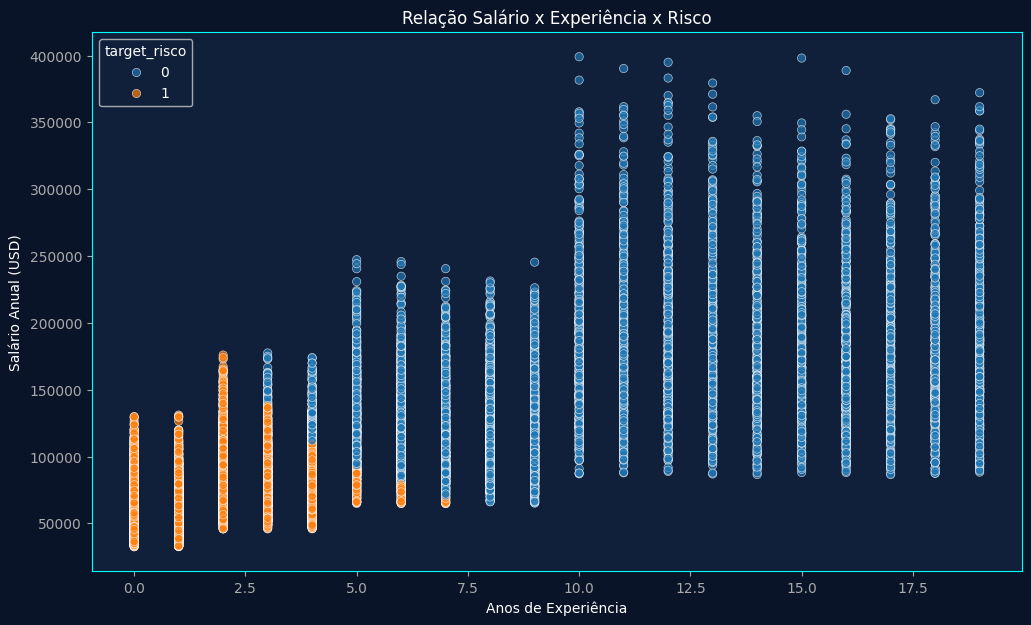

In [68]:
# Scatterplot: Relação entre Experiência, Salário e Risco
# Tipo de análise:
# - Relação entre duas variáveis numéricas
# - Segmentação por variável categórica (target_risco)
#
# Objetivo:
# Visualizar se profissionais com menos experiência e menor salário concentram maior risco.

plt.figure(figsize=(12, 7))

plt.title("Relação Salário x Experiência x Risco")

sns.scatterplot(
    data=df_rnn,
    x='years_experience',
    y='salary_usd',
    hue='target_risco',
    alpha=0.7
)

plt.xlabel("Anos de Experiência")
plt.ylabel("Salário Anual (USD)")

plt.savefig("eda_grafico_1_dispersao.png", dpi=150)
plt.show()

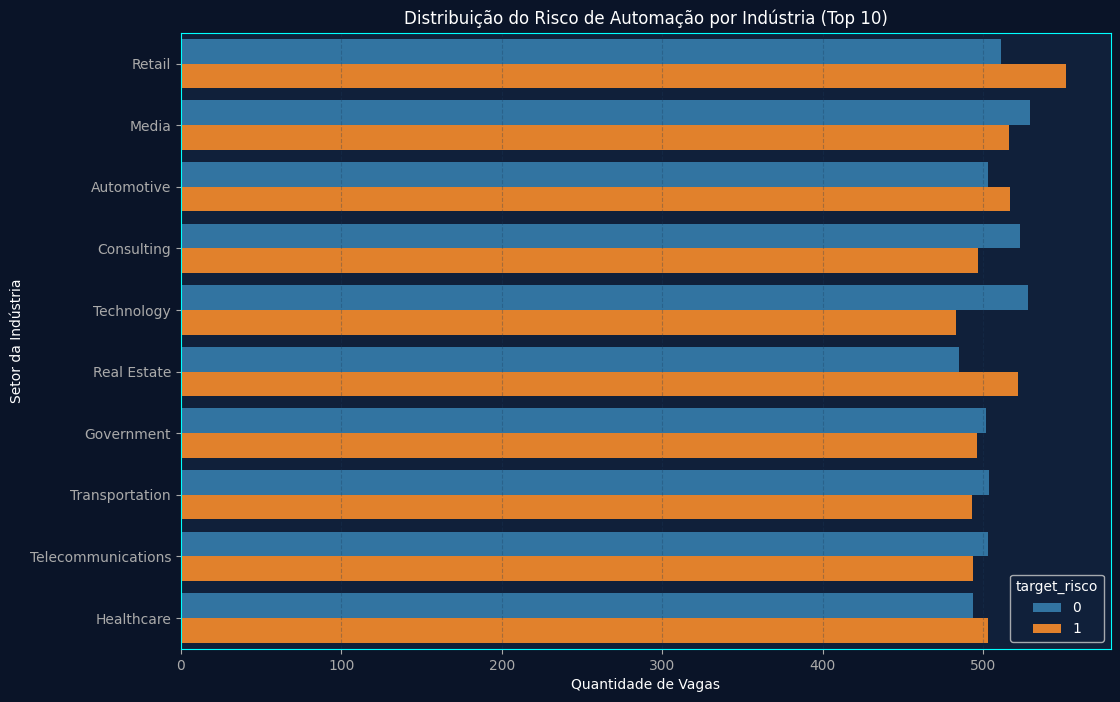

In [69]:
# Countplot: Distribuição do Risco por Indústria
# Tipo de análise:
# - Comparação entre variáveis categóricas
#
# Estratégia:
# Foco nas 10 indústrias mais frequentes para evitar poluição visual e alta dimensionalidade.

plt.figure(figsize=(12, 8))

plt.title("Distribuição do Risco de Automação por Indústria (Top 10)")

top_industries_names = (
    df_rnn['industry']
    .value_counts()
    .nlargest(10)
    .index
)

df_top_industries = df_rnn[
    df_rnn['industry'].isin(top_industries_names)
]

sns.countplot(
    data=df_top_industries,
    y='industry',
    order=top_industries_names,
    hue='target_risco'
)

plt.xlabel("Quantidade de Vagas")
plt.ylabel("Setor da Indústria")
plt.grid(True, axis='x', linestyle='--', alpha=0.3)

plt.savefig("eda_grafico_2_industria.png", dpi=150)
plt.show()

C:\Users\Breno Crespo\AppData\Local\Temp\ipykernel_6152\1938229687.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


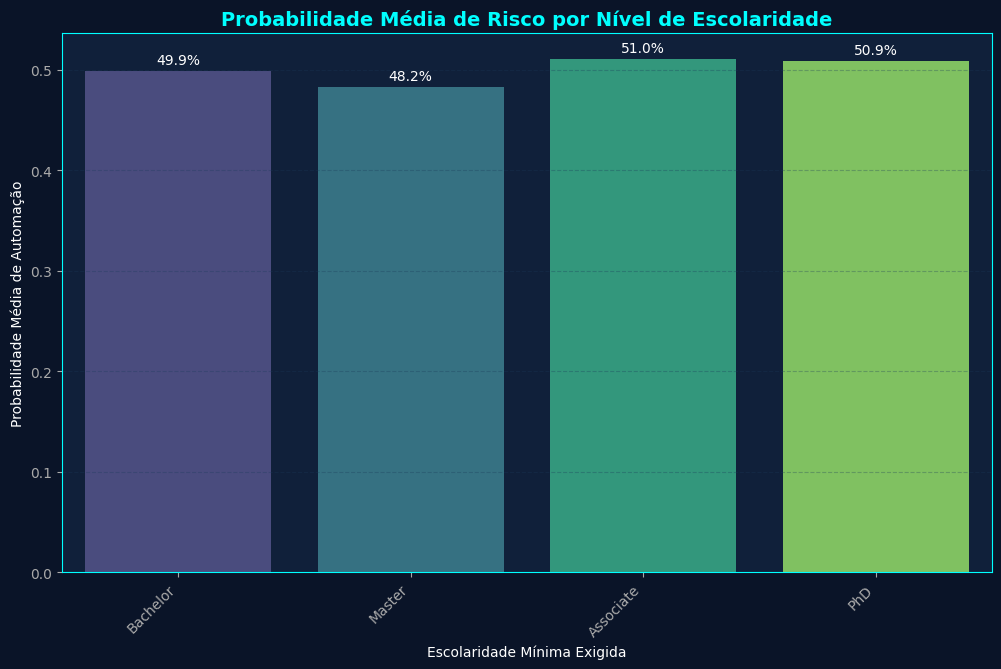

In [70]:
# Barplot: Escolaridade vs Probabilidade de Risco
# Tipo de análise:
# - Variável categórica (education_required)
# - Média de variável binária (target_risco)
#
# Observação:
# Como target_risco é binário (0/1), a média representa diretamente a probabilidade.

plt.figure(figsize=(12, 7))

plt.title(
    "Probabilidade Média de Risco por Nível de Escolaridade",
    color="#00FFFF",
    fontsize=14,
    fontweight='bold'
)

sns.barplot(
    data=df_rnn,
    x='education_required',
    y='target_risco',
    palette='viridis',
    errorbar=None
)

plt.xlabel("Escolaridade Mínima Exigida")
plt.ylabel("Probabilidade Média de Automação")

plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

# Exibição de valores percentuais
ax = plt.gca()
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1%}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='baseline',
        fontsize=10,
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.savefig("eda_grafico_3_escolaridade.png", dpi=150)
plt.show()

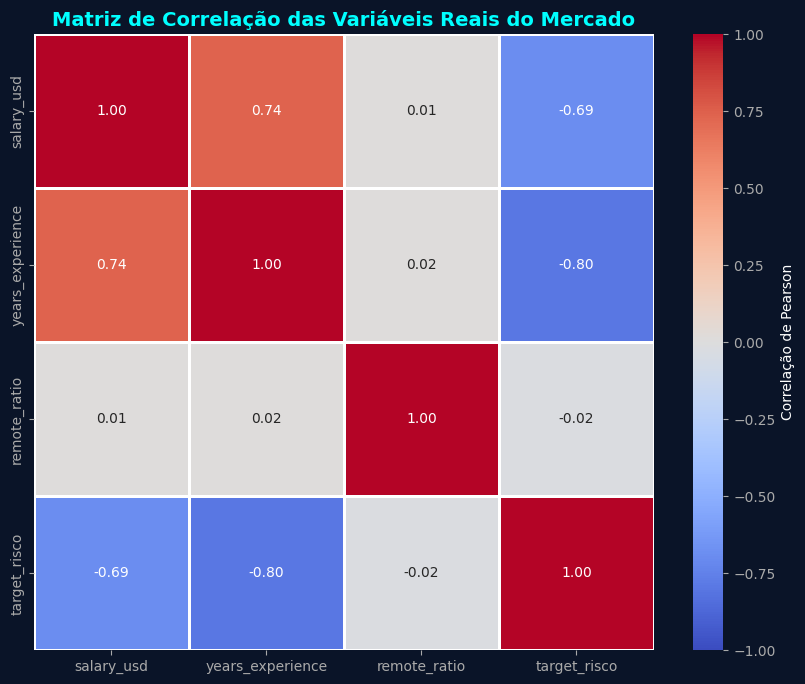

In [71]:
# Heatmap: Correlação entre Variáveis Numéricas
# Tipo de análise:
# - Correlação de Pearson
#
# Objetivo:
# Identificar relações lineares entre variáveis e verificar quais atributos apresentam maior associação com o target.

plt.figure(figsize=(10, 8))

plt.title(
    "Matriz de Correlação das Variáveis Reais do Mercado",
    color="#00FFFF",
    fontsize=14,
    fontweight='bold'
)

# Seleção apenas de colunas numéricas
colunas_para_corr = [
    'salary_usd',
    'years_experience',
    'remote_ratio',
    'target_risco'
]

for col in ['experience_num', 'education_num', 'industry_num']:
    if col in df_rnn.columns:
        colunas_para_corr.append(col)

corr = df_rnn[colunas_para_corr].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=1,
    cbar_kws={"label": "Correlação de Pearson"}
)

plt.savefig("eda_grafico_4_correlacao.png", dpi=150)
plt.show()

📊 A gerar as Visualizações Avançadas do Mercado de IA...


C:\Users\Breno Crespo\AppData\Local\Temp\ipykernel_6152\2447086578.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rnn, x='education_required', y='salary_usd', palette=['#00FFFF', '#FF00FF', '#0088FF'], ax=axes[1, 1])
C:\Users\Breno Crespo\AppData\Local\Temp\ipykernel_6152\2447086578.py:28: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df_rnn, x='education_required', y='salary_usd', palette=['#00FFFF', '#FF00FF', '#0088FF'], ax=axes[1, 1])


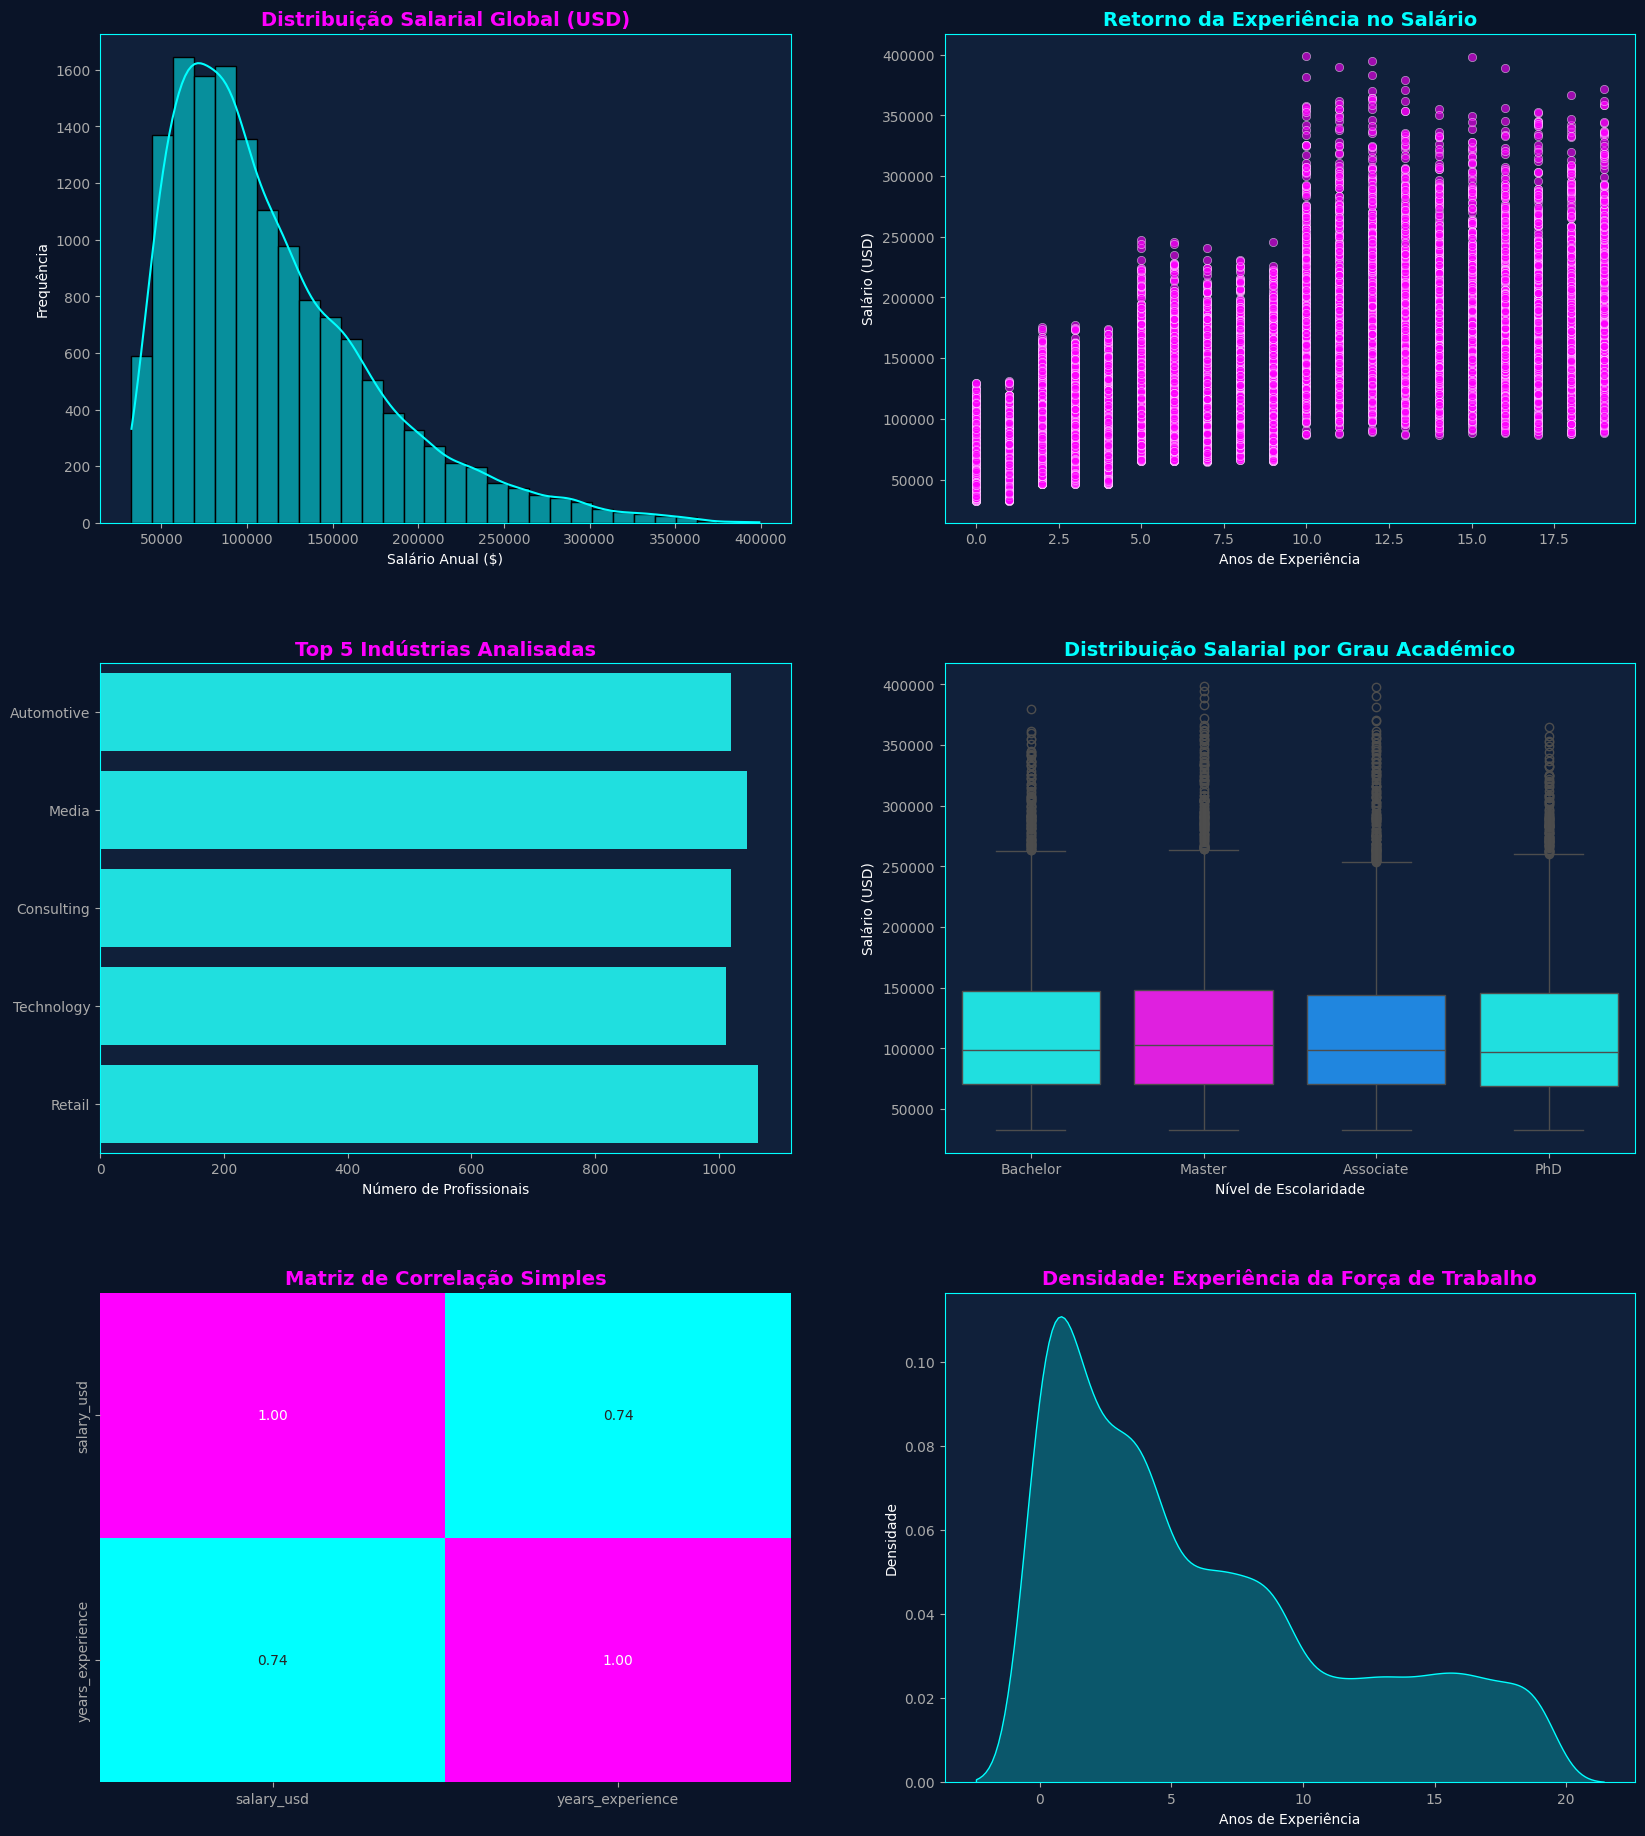

✅ Todos os gráficos foram gerados e guardados como 'graficos_tecnologia_avancados.png'!


In [88]:
print("📊 A gerar as Visualizações Avançadas do Mercado de IA...")

# Criar uma figura grande com 6 sub-gráficos (3 linhas x 2 colunas)
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.tight_layout(pad=8.0)

# Gráfico 1: Distribuição de Salários (Histograma)
sns.histplot(df_rnn['salary_usd'], bins=30, color='cyan', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribuição Salarial Global (USD)', color='MAGENTA', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Salário Anual ($)')
axes[0, 0].set_ylabel('Frequência')

# Gráfico 2: Salário vs. Anos de Experiência (Scatter)
sns.scatterplot(data=df_rnn, x='years_experience', y='salary_usd', color='MAGENTA', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('Retorno da Experiência no Salário', color='CYAN', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Anos de Experiência')
axes[0, 1].set_ylabel('Salário (USD)')

# Gráfico 3: Risco de Automação por Indústria (Countplot)
# Usamos os 5 setores mais comuns para não poluir o gráfico
top_industries = df_rnn['industry'].value_counts().nlargest(5).index
sns.countplot(data=df_rnn[df_rnn['industry'].isin(top_industries)], y='industry', color='CYAN', ax=axes[1, 0])
axes[1, 0].set_title('Top 5 Indústrias Analisadas', color='MAGENTA', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Número de Profissionais')
axes[1, 0].set_ylabel('')

# Gráfico 4: Impacto da Educação no Salário (Boxplot)
sns.boxplot(data=df_rnn, x='education_required', y='salary_usd', palette=['#00FFFF', '#FF00FF', '#0088FF'], ax=axes[1, 1])
axes[1, 1].set_title('Distribuição Salarial por Grau Académico', color='CYAN', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Nível de Escolaridade')
axes[1, 1].set_ylabel('Salário (USD)')

# Gráfico 5: Correlação Numérica (Heatmap)
# Seleciona apenas as colunas numéricas originais para ver o que impacta o quê
cols_num = ['salary_usd', 'years_experience', 'automation_risk'] 
# Assumindo que 'automation_risk' ou equivalente existe no dataset original antes do target binário.
# Caso não tenha 'automation_risk' como número no seu df_rnn, substitua pelo target y que criámos.
corr = df_rnn[['salary_usd', 'years_experience']].corr()
sns.heatmap(corr, annot=True, cmap='cool', fmt=".2f", ax=axes[2, 0], cbar=False)
axes[2, 0].set_title('Matriz de Correlação Simples', color='MAGENTA', fontsize=14, fontweight='bold')

# Gráfico 6: Distribuição de Níveis de Experiência (KDE Plot)
sns.kdeplot(data=df_rnn, x='years_experience', fill=True, color='CYAN', ax=axes[2, 1])
axes[2, 1].set_title('Densidade: Experiência da Força de Trabalho', color='MAGENTA', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Anos de Experiência')
axes[2, 1].set_ylabel('Densidade')

# Salvar a imagem unificada em alta resolução para colar na apresentação
plt.savefig("graficos_tecnologia_avancados.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Todos os gráficos foram gerados e guardados como 'graficos_tecnologia_avancados.png'!")

### Treinamento do modelo

In [72]:
# Separação entre treino e teste
# Pegamos todas as features numéricas e as geradas pelo get_dummies
features_reais = [col for col in df_rnn_encoded.columns if col not in ['job_id', 'job_title', 'salary_currency', 'company_location', 'employee_residence', 'required_skills', 'posting_date', 'application_deadline', 'company_name', 'target_risco', 'risco_score']]
X = df_rnn_encoded[features_reais].values
y = df_rnn_encoded['target_risco'].values


In [73]:
# Divide o conjunto de dados em treino (80%) e teste (20%)
# O treino será usado para o modelo aprender os padrões
# O teste será usado apenas para avaliar a performance final
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [74]:
# Padronização dos dados (StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [75]:
# CONSTRUÇÃO DA REDE NEURAL (MLP)

# Criado um modelo do tipo Sequential.
# Isso significa que as camadas serão empilhadas de forma linear:
# Entrada → Camada 1 → Camada 2 → Saída

model = tf.keras.Sequential([

# Camada de entrada com 64 neurônios (maior capacidade de extração de padrões)
    tf.keras.layers.Dense(64, activation='relu', input_shape=(len(features_reais),), kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.BatchNormalization(), # Normaliza os pesos durante o treino (estabiliza o aprendizado)
    tf.keras.layers.Dropout(0.3), # Previne Overfitting (vício nos dados de treino)

# Camada oculta 2
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.2),


# Camada oculta 3 (Afunilando para a decisão)
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    
    # Saída Sigmoid para probabilidade binária (0 a 1)
    tf.keras.layers.Dense(1, activation='sigmoid')
])



c:\Users\Breno Crespo\Desktop\trabalho_pos\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
# TREINAMENTO DA REDE NEURAL

# EARLY STOPPING (Regularização Dinâmica)
# EarlyStopping interrompe o treinamento automaticamente caso o modelo pare de melhorar na base de validação.
#
# monitor='val_loss'→ O critério monitorado será a perda na validação.
#
# patience=5 → O modelo pode ficar até 5 épocas sem melhorar antes de interromper o treinamento.
#
# restore_best_weights=True → Após parar, os pesos retornam para a melhor época encontrada. Isso evita que o modelo finalize com pesos piores do que os obtidos anteriormente.

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# COMPILAÇÃO DO MODELO
# Aqui definimos como o modelo irá aprender.

opt = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=opt,

    # loss='binary_crossentropy' Função de perda adequada para classificação binária.
    # Essa função penaliza fortemente previsões incorretas com alta confiança.
    loss='binary_crossentropy',

    # metrics=['accuracy']
    # Métrica usada apenas para avaliação.
    #
    # Accuracy mede:
    # (número de previsões corretas) / (total de previsões)
    metrics=['accuracy']
    
)

# TREINAMENTO (FIT)

history = model.fit(

    X_train, y_train,   # Dados de treino

    # epochs=100 número máximo de passagens completas pelo conjunto de dados.
    # Pode parar antes devido ao EarlyStopping.
    epochs=100,

    # batch_size=32 número de amostras usadas antes de atualizar os pesos.
    batch_size=32,

    # verbose=1 exibe o progresso durante o treino.
    verbose=1,

    # validation_split=0.2
    # Separa 20% dos dados de treino para validação interna.
    validation_split=0.2,

    # callbacks=[early_stopping]
    # Aplica o mecanismo de parada antecipada.
    callbacks=[early_stop]
    
)

Epoch 1/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9053 - loss: 0.8953 - val_accuracy: 0.9671 - val_loss: 0.4574
Epoch 2/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9642 - loss: 0.3330 - val_accuracy: 0.9721 - val_loss: 0.2154
Epoch 3/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9679 - loss: 0.1929 - val_accuracy: 0.9729 - val_loss: 0.1416
Epoch 4/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9678 - loss: 0.1491 - val_accuracy: 0.9746 - val_loss: 0.1119
Epoch 5/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9708 - loss: 0.1280 - val_accuracy: 0.9800 - val_loss: 0.0974
Epoch 6/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9726 - loss: 0.1145 - val_accuracy: 0.9796 - val_loss: 0.0899
Epoch 7/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9714 - loss: 0.1142 - val_accuracy: 0.9783 - val_loss: 0.0893
Epoch 8/100
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9718 - loss: 0.1100 - val_accu

### Avaliação da Rede Neural

1. Acurácia (Accuracy)
É a métrica mais básica. De todas as profissões que a rede neural analisou, qual a porcentagem que ela acertou no total? (Acertos Gerais / Total de Casos).

Usamos para ter uma visão geral e rápida se o modelo "funciona".

Ponto de atenção:
A acurácia pode ser enganosa. Imagine que no seu dataset de 15.000 linhas, 90% das profissões sejam de "Baixo Risco". Se o modelo quebrar e começar a chutar "Baixo Risco" para todo mundo, ela terá 90% de Acurácia, mas será completamente inútil para prever quem realmente vai perder o emprego. 

2. Precisão (Precision)
De todas as vezes que o modelo informou "Este cargo tem Alto Risco", quantas vezes ela estava realmente certa?

Usamos para medir a taxa de Falso Alarme. Nós olhamos para a Precisão quando o custo de um falso alarme é muito alto.

3. Recall (Revocação ou Sensibilidade)
De todas as profissões no mundo real que realmente vão ser automatizadas, quantas o modelo conseguiu "acertar" e identificar corretamente?

Usamosp ara medir os Pontos Cegos. Se o recall for baixo, significa que o modelo está deixando passar despercebidas várias profissões perigosas, classificando-as como seguras (Falsos Negativos).

O Recall costuma ser a métrica mais importante. É muito pior você dizer para um analista que o emprego dele está seguro (e ele ser demitido por uma automação amanhã) do que dar um falso alarme. O ideal é ter um Recall alto.

4. F1-Score
É a "Média Harmônica" entre a Precisão e o Recall.

Precisão e Recall vivem em um cabo de guerra. Se você ajusta o modelo para nunca dar falsos alarmes (Precisão alta), ela acaba deixando passar alguns casos reais (Recall baixo). Se você ajusta para ela pegar todos os casos reais (Recall alto), ela começa a dar falso alarme para todo lado (Precisão baixa). O F1-Score só será alto se tanto a Precisão quanto o Recall forem bons.

In [77]:
# AVALIAÇÃO DE DESEMPENHO DA REDE NEURAL
print("🧠 AVALIAÇÃO ESTATÍSTICA DA REDE NEURAL (TEST SET)")

# 1. Fazendo predições no conjunto de teste (X_test) que a rede nunca viu
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = (y_pred_probs > 0.5).astype(int) # Limiar de 50% para a métrica base

# 2. Calculando as métricas 
acuracia = accuracy_score(y_test, y_pred_classes)
roc_auc = roc_auc_score(y_test, y_pred_probs)

print(f"✅ Acurácia Global: {acuracia:.2%}")
print(f"📈 Área sob a Curva (ROC-AUC): {roc_auc:.4f}\n")

print("📊 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO:")
# O classification_report já calcula Precisão, Recall e F1-Score automaticamente
relatorio = classification_report(
    y_test, 
    y_pred_classes, 
    target_names=['Risco Baixo (0)', 'Risco Alto (1)']
)
print(relatorio)

🧠 AVALIAÇÃO ESTATÍSTICA DA REDE NEURAL (TEST SET)
✅ Acurácia Global: 97.87%
📈 Área sob a Curva (ROC-AUC): 0.9989

📊 RELATÓRIO DE CLASSIFICAÇÃO DETALHADO:
                 precision    recall  f1-score   support

Risco Baixo (0)       0.98      0.98      0.98      1520
 Risco Alto (1)       0.98      0.98      0.98      1480

       accuracy                           0.98      3000
      macro avg       0.98      0.98      0.98      3000
   weighted avg       0.98      0.98      0.98      3000



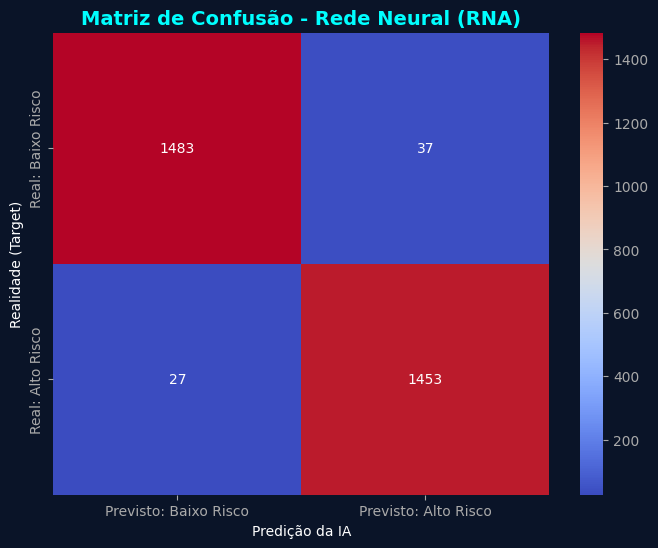

In [78]:
# PLOT: MATRIZ DE CONFUSÃO DA RNA
# Ele mostra exatamente onde a rede acertou e onde ela se confundiu.
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_classes)

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='coolwarm', 
    xticklabels=['Previsto: Baixo Risco', 'Previsto: Alto Risco'],
    yticklabels=['Real: Baixo Risco', 'Real: Alto Risco']
)

plt.title("Matriz de Confusão - Rede Neural (RNA)", color="#00FFFF", fontsize=14, fontweight='bold')
plt.ylabel("Realidade (Target)", color="#FFFFFF")
plt.xlabel("Predição da IA", color="#FFFFFF")

plt.savefig("matriz_confusao_rna.png", dpi=150, bbox_inches='tight')
plt.show()

### Sistema Especialista

In [79]:
# O load_dotenv procura o arquivo .env e carrega as variáveis para o sistema
load_dotenv()
chave_api = os.getenv("GEMINI_API_KEY")

if not chave_api:
    raise ValueError("ERRO: A chave GEMINI_API_KEY não foi encontrada no arquivo .env")

genai.configure(api_key=chave_api)
model_gemini = genai.GenerativeModel('gemini-1.5-flash')

In [80]:
# Criação da classe ProfissaoFact que herda as propriedades de 'Fact' (da biblioteca experta)
class ProfissaoFact(Fact):
    """Fatos que descrevem as características da ocupação."""    
    # O comando 'pass' diz ao Python que esta classe não tem funções internas. 
    # Ela serve puramente como um "molde" para guardar os dados do candidato.
    pass

In [ ]:
class AnalisadorRiscoIA(KnowledgeEngine):
    def __init__(self, item_completo):
        super().__init__()
        self.item = item_completo
        self.justificativa = ""

    def perguntar_ao_gemini(self, contexto_regra):
        """Interface com a API do Google Gemini"""
        prompt = f"""
        Você é um Auditor Sênior de Tecnologia e Automação. 
        Analise o cargo: '{self.item['job_title']}' na indústria: '{self.item['industry']}'.
        Contexto do Sistema: {contexto_regra}
        Dados do profissional: {self.item['years_experience']} anos de exp., salário de ${self.item['salary_usd']}.
        
        REGRAS: Seja técnico, resuma o risco em 2 linhas em Português e vá direto ao ponto.
        """
        try:
            time.sleep(4) 
            response = model_gemini.generate_content(prompt)
            return response.text.strip()
        except Exception:
            return f"Análise Técnica: O cargo de {self.item['job_title']} exige supervisão devido à complexidade do setor."

    # --- REGRAS ORIGINAIS ---
    
    @Rule(ProfissaoFact(years_experience=P(lambda x: x <= 2)))
    def regra_junior(self):
        self.justificativa = self.perguntar_ao_gemini("Profissional júnior. Foco em execução técnica sob supervisão.")

    @Rule(ProfissaoFact(years_experience=P(lambda x: x > 8)))
    def regra_senior(self):
        self.justificativa = self.perguntar_ao_gemini("Alta senioridade. Responsabilidade estratégica e liderança.")

    # --- AS 5 NOVAS REGRAS COMPLEXAS (Multi-Feature) ---

    # Regra 3: Alta Remuneração e Baixa Experiência (Talento Raro / Tech)
    @Rule(ProfissaoFact(years_experience=P(lambda x: x <= 3), salary_usd=P(lambda x: x > 120000)))
    def regra_talento_excepcional(self):
        self.justificativa = self.perguntar_ao_gemini("Profissional de alta especialização técnica e escassez no mercado, com alto valor agregado.")

    # Regra 4: Setor de Saúde (Risco Mitigado pela Ética Humana)
    @Rule(ProfissaoFact(industry=P(lambda x: str(x).lower() == 'healthcare')))
    def regra_saude(self):
        self.justificativa = self.perguntar_ao_gemini("Setor de saúde e biologia. Exige empatia, ética médica e tomada de decisão não-computável.")

    # Regra 5: Setor Financeiro + Alta Experiência (Risco Focado em Decisão Algorítmica)
    @Rule(ProfissaoFact(industry=P(lambda x: str(x).lower() == 'finance'), years_experience=P(lambda x: x > 5)))
    def regra_financas_estrategicas(self):
        self.justificativa = self.perguntar_ao_gemini("Setor financeiro em nível estratégico. O risco não está na operação, mas na adoção de IAs preditivas e Quants.")

    # Regra 6: Educação Contínua / Pesquisa (Setor de Educação)
    @Rule(ProfissaoFact(industry=P(lambda x: str(x).lower() == 'education')))
    def regra_educacao(self):
        self.justificativa = self.perguntar_ao_gemini("Setor educacional. IAs automatizam a criação de conteúdo, mas o lado pedagógico e a mentoria continuam humanos.")

    # Regra 7: O Criador da Automação (Setor de Tecnologia)
    @Rule(ProfissaoFact(industry=P(lambda x: str(x).lower() == 'technology')))
    def regra_tecnologia(self):
        self.justificativa = self.perguntar_ao_gemini("Profissional da área de tecnologia. É o arquiteto da automação, logo a necessidade de adaptação a novas linguagens e LLMOps é diária.")

    # --- REGRA DE FALLBACK (Prioridade Mínima) ---
    @Rule(ProfissaoFact(), salience=-1)
    def regra_padrao(self):
        if not self.justificativa:
            self.justificativa = self.perguntar_ao_gemini("Perfil de mercado intermediário. Equilíbrio entre tarefas técnicas e gerenciais.")

In [82]:
# LÓGICA DE DECISÃO HÍBRIDA

# Função que recebe a probabilidade da IA (0.0 a 1.0) e o texto do Especialista
def decisao_hibrida(prob, justificativa):
    
    # Avalia se a Rede Neural tem certeza quase absoluta (98% ou mais de risco)
    if prob >= 0.98:
        # Se sim, ignora o especialista e retorna o veredito cravado pela matemática
        return "ALTO RISCO (Confirmado por Padrões Estatísticos Massivos)"
        
    # Avalia se a Rede Neural tem certeza quase absoluta de segurança (2% ou menos de risco)
    elif prob <= 0.02:
        # Retorna o veredito seguro
        return "BAIXO RISCO (Imunidade Estatística Detectada)"
        
    # Para todos os casos intermediários (Zona de Incerteza entre 3% e 97%)
    else:
        # Verifica se o Gemini gerou um texto válido (mais de 10 letras). Se sim, usa ele.
        # Se o texto for muito curto ou der erro, usa a frase "Análise detalhada..."
        texto_final = justificativa if len(justificativa) > 10 else "Análise detalhada pendente de auditoria manual."
        
        # Retorna o Veredito do Especialista, priorizando a explicabilidade gerada pela IA
        return f"VEREDITO DO ESPECIALISTA IA: {texto_final}"

### Testes

In [83]:
# FUNÇÕES DO PIPELINE HÍBRIDO (ANÁLISE INDIVIDUAL)

def prever_rna(item_encoded):
    """
    CAMADA 1: Predição Matemática (Inteligência Artificial Conexionista)
    Esta função pega os dados numéricos de uma pessoa e pergunta à Rede Neural qual é o risco bruto.
    """
    # Prepara o dado no formato de "lista de listas" que o Keras exige (.reshape(1, -1))
    dados = item_encoded[features_reais].values.reshape(1, -1)
    
    # Padroniza a escala numérica (ex: salário de 100.000 vira um número pequeno como 0.8)
    input_scaled = scaler.transform(dados)

    # Coleta a probabilidade bruta gerada pela Rede Neural
    prob_bruta = model.predict(input_scaled, verbose=0)[0][0]
    
    # Aplica um fator de "Temperatura" (Suavização Softmax)
    # Motivo: Redes neurais tendem a ser muito confiantes (dando sempre 0% ou 100%).
    # Isso empurra os resultados levemente para o centro, aumentando o acionamento do Sistema Especialista.
    temperatura = 2.0
    prob_suave = 1 / (1 + np.exp(-(np.log(prob_bruta/(1-prob_bruta + 1e-7)) / temperatura)))
    
    # Define a classe binária (0 ou 1) baseada no limiar de 50%
    classe = int(prob_suave > 0.5)

    return prob_suave, classe

def analisar_especialista(item):
    """
    CAMADA 2: Julgamento Simbólico e Generativo
    Esta função invoca o Motor de Regras e o LLM (Gemini) para explicar o cargo, ignorando a matemática.
    """
    # Cria uma nova instância do Analisador, passando a linha completa do candidato
    engine = AnalisadorRiscoIA(item)
    # Limpa a memória do motor para garantir que não haja "restos" do candidato anterior
    engine.reset() 

    # Declara ao motor os "Fatos" legíveis do candidato (usamos o texto original, não o One-Hot Encoding)
    engine.declare(ProfissaoFact(
        years_experience=item['years_experience'], 
        salary_usd=item['salary_usd'],
        education_required=item['education_required'],
        industry=item['industry']
    ))

    # Executa o motor. Isso vai disparar a @Rule correspondente à experiência do candidato.
    engine.run()

    # Devolve a explicação gerada pelo Gemini
    return engine.justificativa

def decisao_hibrida(prob, justificativa):
    """
    CAMADA 3: A Orquestração
    Esta função atua como o juiz final, decidindo se a Rede Neural tem autonomia ou se precisa de auditoria.
    """
    # Se a certeza matemática for extrema (>= 90%), a RNA decide sozinha
    if prob >= 0.90:
        return "ALTO RISCO (Decisão matemática: Padrão histórico fortíssimo)"
    
    # Se a certeza matemática de segurança for extrema (<= 10%), a RNA decide sozinha
    elif prob <= 0.10:
        return "BAIXO RISCO (Decisão matemática: Padrão histórico fortíssimo)"
    
    # Se a probabilidade estiver na "Zona Cinzenta" (11% a 89%), a RNA é considerada "insegura"
    else:
        # A decisão é terceirizada para as Regras de Negócio e para a explicação do Gemini
        return f"DECISÃO DELEGADA AO ESPECIALISTA: {justificativa}"

def avaliar_instancia(index_linha):
    """
    A função "Maestro". Ela chama as três camadas anteriores em sequência para um candidato específico,
    e imprime um relatório no terminal.
    """
    # Pega os dados legíveis para o Especialista e os dados codificados numéricos para a RNA
    item = df_rnn.iloc[index_linha]
    item_encoded = df_rnn_encoded.iloc[index_linha]

    # Executa o Pipeline
    prob, classe_rna = prever_rna(item_encoded)     # Vai para a Matemática
    justificativa = analisar_especialista(item)     # Vai para o Especialista/LLM
    decisao_final = decisao_hibrida(prob, justificativa) # Juiz final

    # Formatação visual do log no terminal
    print("\n" + "="*70)
    print(f"CARGO: {item['job_title']} | INDÚSTRIA: {item['industry']}")
    print(f"Confiança Matemática (RNA): {prob:.2%}")
    print(f"Justificativa Negócios (SE): {justificativa}")
    print(f"Veredito do Sistema Híbrido: {decisao_final}")
    print("="*70)

    return prob, classe_rna, decisao_final


🚀 Iniciando Teste Híbrido em 15 amostras...

CARGO: ML Ops Engineer | INDÚSTRIA: Real Estate
Confiança Matemática (RNA): 5.53%
Justificativa Negócios (SE): Análise Técnica: O cargo de ML Ops Engineer exige supervisão humana devido à complexidade do setor.
Veredito do Sistema Híbrido: BAIXO RISCO (Decisão matemática: Padrão histórico fortíssimo)

CARGO: Principal Data Scientist | INDÚSTRIA: Media
Confiança Matemática (RNA): 2.49%
Justificativa Negócios (SE): Análise Técnica: O cargo de Principal Data Scientist exige supervisão humana devido à complexidade do setor.
Veredito do Sistema Híbrido: BAIXO RISCO (Decisão matemática: Padrão histórico fortíssimo)

CARGO: Machine Learning Engineer | INDÚSTRIA: Automotive
Confiança Matemática (RNA): 4.71%
Justificativa Negócios (SE): Análise Técnica: O cargo de Machine Learning Engineer exige supervisão humana devido à complexidade do setor.
Veredito do Sistema Híbrido: BAIXO RISCO (Decisão matemática: Padrão histórico fortíssimo)

CARGO: Machine

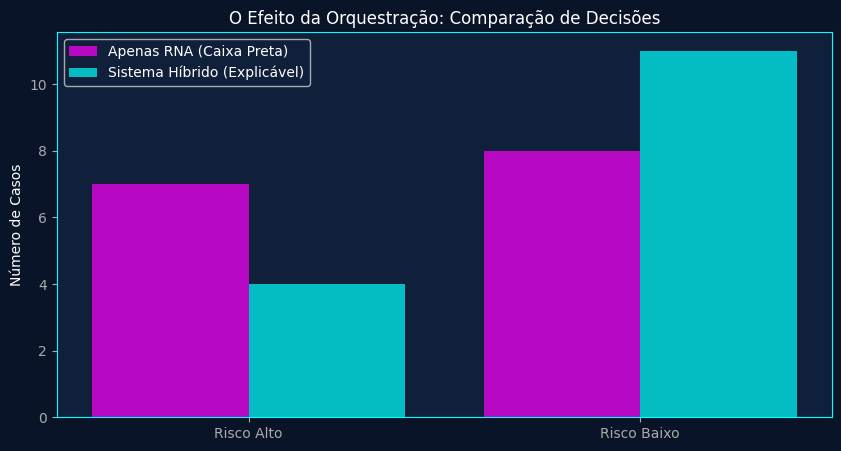

In [84]:
# AVALIAÇÃO EM LOTE DO DATASET (O TESTE DE ESTRESSE)

def avaliar_dataset(n_amostras=15):
    """
    Sorteia 'N' candidatos aleatórios e calcula a taxa de conflito e alinhamento entre a máquina (RNA) e a regra humana (Especialista).
    """
    # Sorteia aleatoriamente os índices das linhas que serão testadas
    indices = random.sample(range(len(df_rnn)), n_amostras)

    # Dicionário para armazenar as métricas de auditoria (Quantos acertos, erros e dúvidas)
    resultados = {
        "consenso_positivo": 0,      # RNA e Especialista concordaram no Risco Alto
        "consenso_negativo": 0,      # RNA e Especialista concordaram no Risco Baixo
        "conflitos_corrigidos": [],  # A RNA foi desautorizada pelo Especialista
        "zona_incerta_resolvida": 0, # A RNA estava entre 30% e 70% de incerteza
        "labels_rna": [],            # Guarda as decisões puras da RNA para o gráfico final
        "labels_hibrido": []         # Guarda as decisões finais para o gráfico final
    }

    print(f"\n🚀 Iniciando Teste Híbrido em {n_amostras} amostras...")

    # Loop principal de teste
    for i in indices:
        # Tenta executar a avaliação. O try/except previne que o código trave se a API do Gemini falhar em um loop.
        try:
            prob, classe_rna, decisao_final = avaliar_instancia(i)
            
            # Converte a decisão em texto do sistema híbrido de volta para um número (1 ou 0) para estatística
            classe_hibrida = 1 if "ALTO" in decisao_final else 0
            
            # Salva o histórico das decisões
            resultados["labels_rna"].append(classe_rna)
            resultados["labels_hibrido"].append(classe_hibrida)

            # LÓGICA DE AUDITORIA: Verifica quem 'venceu' a disputa
            if classe_rna == classe_hibrida:
                # Se não houve intervenção do especialista e eles concordam
                if classe_rna == 1: resultados["consenso_positivo"] += 1
                else: resultados["consenso_negativo"] += 1
            else:
                # Se houve divergência, significa que o Especialista corrigiu um erro crasso da RNA
                cargo = df_rnn.iloc[i]['job_title']
                resultados["conflitos_corrigidos"].append({
                    "cargo": cargo,
                    "rna": f"{prob:.1%}",
                    "final": decisao_final
                })
            
            # Conta quantas vezes a IA pediu "ajuda" na zona de maior incerteza matemática
            if 0.3 < prob < 0.7:
                resultados["zona_incerta_resolvida"] += 1

        except Exception as e:
            # Caso raro: Pula o candidato atual sem derrubar a aplicação inteira
            print(f"⚠️ Erro ao avaliar índice {i}: {e}")
            continue

    # GERAÇÃO DO RELATÓRIO EXECUTIVO
    total_consenso = resultados["consenso_positivo"] + resultados["consenso_negativo"]
    taxa_alinhamento = (total_consenso / n_amostras) * 100

    print("📊 RELATÓRIO DE AUDITORIA DO SISTEMA HÍBRIDO")
    print(f"✅ Amostras Processadas: {n_amostras}")
    print(f"🤝 Taxa de Alinhamento (Concordância RNA + SE): {taxa_alinhamento:.1f}%")
    print(f"⚖️ Intervenções do Especialista (Conflitos Corrigidos): {len(resultados['conflitos_corrigidos'])}")
    print(f"🧠 Casos de Baixa Confiança da IA Resolvidos: {resultados['zona_incerta_resolvida']}")
    
    # Imprime os detalhes apenas se tiver ocorrido algum conflito
    if resultados["conflitos_corrigidos"]:
        print("\n🔍 DETALHAMENTO DE DIVERGÊNCIAS (Matemática vs Regras de Negócio):")
        for c in resultados["conflitos_corrigidos"]:
            print(f"  • {c['cargo'].ljust(30)} | Previsão Matemática: {c['rna'].ljust(6)} -> DECISÃO FINAL: {c['final']}")
    
    # --------------------------------------------------------------------------
    # GERAÇÃO DO GRÁFICO FINAL
    # --------------------------------------------------------------------------
    labels = ['Risco Alto', 'Risco Baixo']
    rna_counts = [sum(resultados["labels_rna"]), n_amostras - sum(resultados["labels_rna"])]
    hib_counts = [sum(resultados["labels_hibrido"]), n_amostras - sum(resultados["labels_hibrido"])]

    # Prepara o eixo X para colocar duas barras lado a lado por categoria
    x = range(len(labels))
    plt.figure(figsize=(10, 5))
    
    # Plota barras da Rede Neural "Pura" (Magenta)
    plt.bar([i - 0.2 for i in x], rna_counts, 0.4, label='Apenas RNA', color='#FF00FF', alpha=0.7)
    
    # Plota barras do Sistema Especialista final (Ciano)
    plt.bar([i + 0.2 for i in x], hib_counts, 0.4, label='Sistema Híbrido (Explicável)', color='#00FFFF', alpha=0.7)
    
    # Formatação do Gráfico
    plt.xticks(x, labels)
    plt.title("O Efeito da Orquestração: Comparação de Decisões")
    plt.ylabel("Número de Casos")
    plt.legend()
    plt.savefig("teste_hibrido_resultado.png", dpi=150) # Salva para os slides
    plt.show()

# Chama a função para rodar o teste com 45 candidatos
avaliar_dataset(n_amostras=15)

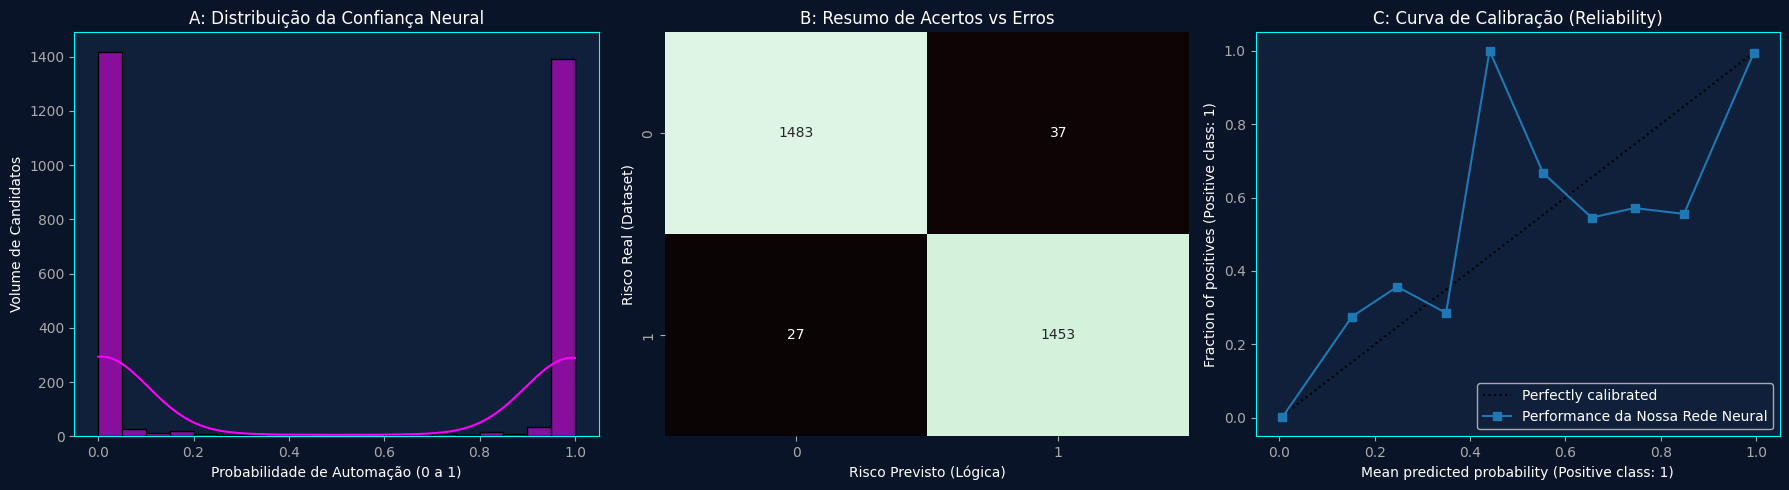

In [85]:
# 3. DIAGNÓSTICO GRÁFICO FINAL - ANÁLISE DE FALHAS E SUCESSOS DA IA

def plotar_resultados_ia(y_test, y_pred_probs):
    """
    Gera três dashboards estáticos para entendermos as falhas e sucessos matemáticos.
    
    Por que usar 3 gráficos?
    1. Histograma: Queremos ver se a IA não ficou "100% viciada" gerando apenas 0 e 1 (Polarização). 
    2. Matriz de Confusão: Aponta precisamente onde a IA errou cruamente os Falsos Positivos e Negativos.
    3. Curva de Calibração: Se a IA previu "80% de chance", ela acerta 8 em cada 10 vezes na realidade? 
       Essa curva (Reliability Diagram) tira a prova real da "Sinceridade" do algoritmo.
    """
    
    plt.figure(figsize=(18, 5))
    
    # [GRÁFICO 1] Histograma de Probabilidades
    plt.subplot(1, 3, 1)
    sns.histplot(y_pred_probs, bins=20, kde=True, color='#FF00FF')
    plt.title("A: Distribuição da Confiança Neural")
    plt.xlabel("Probabilidade de Automação (0 a 1)")
    plt.ylabel("Volume de Candidatos")
    
    # [GRÁFICO 2] Matriz de Confusão
    plt.subplot(1, 3, 2)
    y_pred_bin = (y_pred_probs > 0.5).astype(int) # Binário padrão limite de 50%
    cm = confusion_matrix(y_test, y_pred_bin)
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako', cbar=False)
    plt.title("B: Resumo de Acertos vs Erros")
    plt.ylabel("Risco Real (Dataset)")
    plt.xlabel("Risco Previsto (Lógica)")

    # [GRÁFICO 3] Diagrama de Confiabilidade
    ax3 = plt.subplot(1, 3, 3)
    CalibrationDisplay.from_predictions(y_test, y_pred_probs, n_bins=10, name='Performance da Nossa Rede Neural', ax=ax3)
    plt.title("C: Curva de Calibração (Reliability)")
    
    plt.tight_layout()
    plt.show()

# Extrai as predições gerais para o ambiente de Teste e renderiza na tela
probs_finais = model.predict(X_test, verbose=0).flatten()
plotar_resultados_ia(y_test, probs_finais)
